<a href="https://colab.research.google.com/github/canadianderssop/canadianderssop/blob/main/network_classv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Functional Network Classifier v8
Uses helper functions provided by Nilearn

General idea:

1.   Uses 3 atlases (Smith, Schaefer, and MIST122).
2.   Spatial correlation of the functional networks in each atlas against atoms.
3.   Take average score of all atlases for single functional network and compare against other functional networks.
4.   Select one with the highest score to classify.




In [ ]:
# Relevant imports
!pip install nilearn
import numpy as np
import matplotlib.pyplot as plt
from nilearn.maskers import NiftiMapsMasker
from nilearn import datasets, image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


# Import Smith Atlas


In [ ]:
# Add Smith Atlas
# Fetch Functional Atlases (Smith 2009 for Large-scale networks)
smith_20 = datasets.fetch_atlas_smith_2009(dimension=20)
smith_maps = smith_20.maps

# Fetch Structural Atlases (Harvard-Oxford & AAL for deep nuclei / lobes)
ho_cort = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_sub = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')
aal = datasets.fetch_atlas_aal()

# Helper function to grab anatomical region masks
def create_integer_mask(atlas_img, integer_ids):
    if isinstance(integer_ids, int):
        integer_ids = [integer_ids]
    # Build an expression checking if voxel matches any required label ID
    expression = " + ".join([f"(img == {idx})" for idx in integer_ids])
    return image.math_img(f"({expression}) > 0", img=atlas_img)

[fetch_atlas_smith_2009] Added README.md to /root/nilearn_data

[fetch_atlas_smith_2009] Dataset created in /root/nilearn_data/smith_2009

[fetch_atlas_smith_2009] Downloading data from https://www.fmrib.ox.ac.uk/datasets/brainmap+rsns/rsn20.nii.gz ...

[fetch_atlas_smith_2009] Downloaded 8888320 of 15129514 bytes (58.7%%, 00 HR 00 MIN 01 SEC remaining)

[fetch_atlas_smith_2009]  ...done. (2 seconds, 0 min)

...

[fetch_atlas_aal] Error while fetching file AAL3v2_for_SPM12.tar.gz; dataset fetching aborted.

[fetch_atlas_aal] Downloading data from https://osf.io/6jngh/download ...

[fetch_atlas_aal]  ...done. (4 seconds, 0 min)

[fetch_atlas_aal] Extracting data from /root/nilearn_data/aal_3v2/4f110dbf3403fb75926011e54dc0dcec/download...

[fetch_atlas_aal] .. done.

*Some functional networks have been commented out since they negatively affect the accuracy/generalizability of the classifier

In [ ]:
# Construct the comprehensive 15-class dictionary
# Mapping explicit requested categories to exact index or anatomical bounds
templates_smith = {
    # Large scale functional resting state networks (Smith 2009 20-ICA)
    "dmn": image.index_img(smith_maps, 13),
    "dan": image.index_img(smith_maps, 10),          # Dorsal Attention Network
    "salience": image.index_img(smith_maps, 5),
    # "executive control": image.index_img(smith_maps, 17),
    # "sensorimotor": image.index_img(smith_maps, 6),

    # "auditory": image.index_img(smith_maps, 16),
    "visuospatial": image.index_img(smith_maps, 11),  # Parieto-frontal network
    "visual lateral": image.index_img(smith_maps, 1),
    "visual medial": image.index_img(smith_maps, 0),
    "visual occipital": image.index_img(smith_maps, 2),


    # Precise Subregions and Deep Structures
    "hippocampus": create_integer_mask(ho_sub.maps, [9, 19]),            # Left (9) and Right (19) Hippocampus
    "precuneus": create_integer_mask(ho_cort.maps, 31),                  # Region 31: Precuneus Cortex
    "subcortical": create_integer_mask(ho_sub.maps, [4, 5, 15, 16]),     # Combined Left/Right Thalamus & Caudate
    "temporal lobe": create_integer_mask(ho_cort.maps, [7, 8, 9, 10]),   # Middle/Inferior Temporal Gyri

    # Cerebellum (Automated via AAL structural mask logic)
    "cerebellum": image.math_img("img > 90", img=aal.maps)
}

# Import Schaefer Atlas

In [ ]:
# Add Schaefer Atlas
# Fetch the 400 region, 17-network Schaefer map
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=17, resolution_mm=2)
schaefer_map = schaefer.maps
schaefer_labels = schaefer.labels

[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_17Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_400Parcels_17Networks_order_FSLMNI152_2mm
.nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

In [ ]:
"_DorsAttnA_" in schaefer.labels

False

In [ ]:
# Schaefer Mapping
network_mapping_keywords = {
    "dmn": ["_DefaultA_", "_DefaultB_"],            # Main Default Mode components
    "dan": ["_DorsAttnA_", "_DorsAttnB_"],
    "salience": ["_SalVentAttnA_", "_SalVentAttnB_"],
    "executive control": ["_ContA_", "_ContB_", "_ContC_"], # Control networks
    "sensorimotor": ["_SomMotA_", "_SomMotB_"],

    "auditory": ["_SomMotB_"],
    # "visuospatial": ["_DorsAttnA_", "_DorsAttnB_"],
    "visual medial": ["_VisPeri_"],
    "visual lateral": ["_VisCent_"],
    "visual occipital": ["_VisCent_", "_VisPeri_"], # Broad overlap area                   # Auditory clusters border SomMotB regions

    "hippocampus": ["_LimbicB_"],
    "precuneus": ["_DefaultC_"],
    # "subcortical": ["_Striatum_"],
    # "temporal lobe": ["_LimbicA_", "_Temporal_"],
    # "cerebellum": ["_Cerebellum_"]                    # Border regions targeting parahippocampal cortex
}

In [ ]:
templates_schaefer = {}
for system_name, keywords in network_mapping_keywords.items():
    matching_ids = []
    # Loop over the 400 integer region indexes in the atlas (Background is index 0)
    for idx, label_bytes in enumerate(schaefer_labels):
        label_str = label_bytes
        if any(kw in label_str for kw in keywords):
            matching_ids.append(idx + 1) # Regions inside deterministic arrays are 1-indexed

    if matching_ids:
        # Build an algebraic string expression to merge matching regional voxels into one single mask
        expression = " + ".join([f"(img == {region_id})" for region_id in matching_ids])
        templates_schaefer[system_name] = image.math_img(f"({expression}) > 0", img=schaefer_map)

# Import MIST Data


In [ ]:
from nilearn.datasets import fetch_atlas_basc_multiscale_2015
mist = fetch_atlas_basc_multiscale_2015(
    resolution=122)


[fetch_atlas_basc_multiscale_2015] Dataset created in /root/nilearn_data/basc_multiscale_2015

[fetch_atlas_basc_multiscale_2015] Downloading data from https://ndownloader.figshare.com/files/1861819 ...

[fetch_atlas_basc_multiscale_2015]  ...done. (1 seconds, 0 min)

[fetch_atlas_basc_multiscale_2015] Extracting data from 
/root/nilearn_data/basc_multiscale_2015/52084ff89fb751bc5ac184b320fdae35/1861819...

[fetch_atlas_basc_multiscale_2015] .. done.

In [ ]:
# MIST_122_MAPPING w/o DAN + Hippocampus
MIST_122_MAPPING = {
    "auditory": [
        88,   # SUPERIOR_TEMPORAL_GYRUS_middle
        99,   # HESCHLS_GYRUS
        119,  # SUPERIOR_TEMPORAL_GYRUS_posterior
    ],

    "cerebellum": [
        3, 9, 11, 14, 18, 44, 46, 48,
        54, 62, 65, 84, 90, 97, 108, 121
    ],

    "dmn": [
        15,   # right ANGULAR_GYRUS
        24,   # POSTERIOR_CINGULATE_CORTEX
        27,   # POSTERIOR_CINGULATE_CORTEX
        33,   # left ANGULAR_GYRUS
        34,   # DORSOMEDIAL_PREFRONTAL_CORTEX_posterior
        35,   # VENTRAL_MEDIAL_PREFRONTAL_CORTEX_posterior
        61,   # MEDIAL_ORBITAL_GYRUS
        66,   # VENTRAL_MEDIAL_PREFRONTAL_CORTEX_anterior
        115,  # PERIGENUAL_ANTERIOR_CINGULATE_CORTEX
    ],

    "executive control": [
        4, 7, 22, 38, 53, 58, 59, 63,
        75, 77, 80, 91, 92, 94, 98,
        105, 109, 111, 114, 120
    ],

    "precuneus": [
        17,   # PRECUNEUS_ventral
        47,   # PRECUNEUS_dorsal
        64,   # PRECUNEUS_dorsal
    ],

    "salience": [
        6,    # ANTERIOR_CINGULATE_CORTEX_dorsal
        12,   # ANTERIOR_INSULA_ventral
        21,   # POSTERIOR_INSULA_ventral
        23,   # ANTERIOR_INSULA_posterodorsal
        30,   # PERI_INSULAR_SULCUS
        52,   # POSTERIOR_INSULA_dorsal
        85,   # ANTERIOR_INSULA_anterodorsal
    ],

    "sensorimotor": [
        5, 8, 28, 37, 67, 68,
        73, 93, 102, 110, 116, 122
    ],

    "subcortical": [
        2,    # CAUDATE_ventral
        10,   # CAUDATE_dorsal
        13,   # PUTAMEN_anterior
        25,   # PUTAMEN_posterior
        31,   # THALAMUS_dorsal
        36,   # THALAMUS_ventral
        42,   # HIPPOCAMPUS
        45,   # CAUDATE
        71,   # AMYGDALA
        78,   # CAUDATE HEAD / NUCLEUS ACCUMBENS
    ],

    "temporal lobe": [
        32,   # right MIDDLE_TEMPORAL_GYRUS_anterior
        49,   # FUSIFORM_GYRUS_ventrolateral
        70,   # TEMPORAL_POLE
        79,   # COLLATERAL_SULCUS
        82,   # left MIDDLE_TEMPORAL_GYRUS_posterior
        86,   # SUPERIOR_TEMPORAL_GYRUS_anterior
        89,   # left MIDDLE_TEMPORAL_GYRUS_anterior
        104,  # FUSIFORM_GYRUS_dorsolateral
        106,  # right MIDDLE_TEMPORAL_GYRUS_posterior
        112,  # INFERIOR_TEMPORAL_GYRUS
    ],

    "visual lateral": [
        39,   # LATERAL_VISUAL_NETWORK_posterior
        43,   # LATERAL_VISUAL_NETWORK_dorsoposterior
        81,   # LATERAL_VISUAL_NETWORK_ventroposterior
        101,  # VENTRAL_VISUAL_NETWORK_lateral
        117,  # OCCIPITOTEMPORAL_GYRUS_lateral
    ],

    "visual medial": [
        19,   # MEDIAL_VISUAL_NETWORK_anterodorsal
        29,   # MEDIAL_VISUAL_NETWORK_anteroventral
        40,   # VENTRAL_VISUAL_NETWORK_medial
        51,   # MEDIAL_VISUAL_NETWORK_posterior
        107,  # POSTERIOR_VISUAL_NETWORK_ventromedial
    ],

    "visual occipital": [
        16,   # POSTERIOR_VISUAL_NETWORK_dorsomedial
        56,   # MEDIODORSAL_VISUAL_NETWORK_anterior
        57,   # MEDIODORSAL_VISUAL_NETWORK_posterior
        60,   # POSTERIOR_VISUAL_NETWORK_lateral
    ],

    "visuospatial": [
        1,    # SUPERIOR_PARIETAL_LOBULE
        20,   # right INTRAPARIETAL_SULCUS
        26,   # CINGULATE_SULCUS_posterior
        50,   # left DORSAL_VISUAL_STREAM_ventral
        69,   # right DORSAL_VISUAL_STREAM_ventral
        72,   # PARIETO_OCCIPITAL_SULCUS_ventral
        74,   # left INTRAPARIETAL_SULCUS
        76,   # SUPERIOR_PARIETAL_LOBULE
        83,   # DORSAL_VISUAL_STREAM_superior
        95,   # SUPRAMARGINAL_GYRUS
        96,   # PARIETO_OCCIPITAL_SULCUS_dorsal
        100,  # DORSAL_VISUAL_STREAM_ventrolateral
        103,  # PARIETO_OCCIPITAL_SULCUS
        113,  # FRONTAL_EYE_FIELD
        118,  # INFERIOR_MARGINAL_SULCUS
    ],
}

Code to manually create templates for each functional network for MIST122

In [ ]:
import nibabel as nib
atlas = nib.load(mist.maps)
data = atlas.get_fdata()

templates_mist = {}

for network, roi_ids in MIST_122_MAPPING.items():

    mask = np.isin(data, roi_ids).astype(np.uint8)

    templates_mist[network] = nib.Nifti1Image(
        mask,
        atlas.affine,
        atlas.header
    )

# Import Atoms From Google Drive to Classify

On Google Colab, import the atoms that SPARK outputs to a folder on your Google drive and modify the "HC043_atom_folder..." path accordingly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re

#Load atoms from subjects (using path to folder)
HC043_atom_folder = "/content/drive/My Drive/training-data/HC043_session1_run1"
HC044_atom_folder = "/content/drive/My Drive/training-data/HC044_session1_run1"
HC048_atom_folder = "/content/drive/My Drive/training-data/HC048_session1_run1"

subjects = [HC043_atom_folder, HC044_atom_folder, HC048_atom_folder]

def atom_num(name):
    m = re.search(r"atom(\d+)", name)
    return int(m.group(1)) if m else float("inf")


HC043_atom_dict = {}
HC043_atom_path = {}

HC044_atom_dict = {}
HC044_atom_path = {}

HC048_atom_dict = {}
HC048_atom_path = {}

for subject in subjects:
    atom_names = sorted(os.listdir(subject), key=atom_num)
    for index, atom_name in enumerate(atom_names, start=1):
        img_path = os.path.join(subject, atom_name)
        if subject == HC043_atom_folder:
            HC043_atom_dict[index] = image.load_img(img_path)
            HC043_atom_path[index] = img_path
        elif subject == HC048_atom_folder:
            HC048_atom_dict[index] = image.load_img(img_path)
            HC048_atom_path[index] = img_path
        else:
            HC044_atom_dict[index] = image.load_img(img_path)
            HC044_atom_path[index] = img_path


print("\n--- Running Multi-Atlas Core Classifier ---")

HC048_atom_dict


--- Running Multi-Atlas Core Classifier ---


{1: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67b410>,
 2: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67b5c0>,
 3: <nibabel.nifti1.Nifti1Image at 0x7ca1cf679880>,
 4: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67b770>,
 5: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67b800>,
 6: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67b890>,
 7: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67b920>,
 8: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67b9b0>,
 9: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67ba40>,
 10: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67bd10>,
 11: <nibabel.nifti1.Nifti1Image at 0x7ca1cf67bec0>,
 12: <nibabel.nifti1.Nifti1Image at 0x7ca1cf6980e0>,
 13: <nibabel.nifti1.Nifti1Image at 0x7ca1cf698290>,
 14: <nibabel.nifti1.Nifti1Image at 0x7ca1cf698440>,
 15: <nibabel.nifti1.Nifti1Image at 0x7ca1cf6985f0>,
 16: <nibabel.nifti1.Nifti1Image at 0x7ca1cf6987a0>,
 17: <nibabel.nifti1.Nifti1Image at 0x7ca1cf698950>,
 18: <nibabel.nifti1.Nifti1Image at 0x7ca1cf698b00>,
 19: <nibabel.nifti1.Nifti1Image at 0x7ca1cf698cb0>,
 2

# Classifying Engine


In [ ]:
import statistics


# Helpers to infer which template comes from which atlas
def normalize_templates(templates):
    normalized = []
    for entry in templates:
        atlas_name, atlas_dict = entry
        normalized.append((atlas_name, atlas_dict))
    return normalized


# Linear Similarity via Spatial Correlation
def classify_dp(subject_atom_dict, labels, templates):
    "Returns dict of top 3 classification results as top_classification_results"
    top_classification_results = {}
    all_scores = {}

    template_groups = normalize_templates(templates)

    # DP Cache: Keyed by (target_grid_shape, atlas_name, label)
    dp_template_cache = {}

    for i, subject_atom in enumerate(subject_atom_dict.values(), start=1):
        # 1. Pre-calculate current vector operations
        current_vector = np.nan_to_num(subject_atom.get_fdata().flatten())
        current_std = np.nanstd(current_vector)
        atom_scores = []

        for name in labels:
            atlas_scores = []

            for atlas_name, template_dict in template_groups:
                if name not in template_dict:
                    continue

                # Create unique sub-problem state key for DP lookup
                cache_key = (
                            subject_atom.shape,
                            tuple(subject_atom.affine.flatten()),
                            atlas_name,
                            name
                            )

                # Retrieve if sub_problem already solved
                if cache_key in dp_template_cache:
                    vol_data = dp_template_cache[cache_key]
                else:
                    # DP Miss: Compute, format, and store sub-problem
                    resampled_template = image.resample_to_img(
                        template_dict[name],
                        subject_atom,
                        interpolation='nearest'
                    )
                    atlas_data = np.nan_to_num(resampled_template.get_fdata())
                    vol_data = atlas_data.flatten()


                    # Save state to cache
                    dp_template_cache[cache_key] = (vol_data)

                # Correlation Engine
                if np.nanstd(vol_data) == 0 or current_std == 0:
                    correlation = 0.0
                else:
                    correlation = np.corrcoef(current_vector, vol_data)[0, 1]
                    if np.isnan(correlation):
                        correlation = 0.0
                atlas_scores.append(abs(correlation))

            # Get average score for each atlas used
            score = statistics.mean(atlas_scores) if atlas_scores else 0.0
            if score < 0.18:
                label = "noise"
            else:
                label = name
            atom_scores.append((score, label.lower()))

        # Post-processing optimization (only once per subject atom)
        # Store all the labels and scores by descending order of scores
        atom_scores.sort(reverse=True, key=lambda x: x[0])
        top3 = atom_scores[:3]
        top_classification_results[i] = [
            {"label": name, "score": score} for score, name in top3
        ]

        all_scores[i] = [
            {"label": name, "score": score} for score, name in atom_scores
        ]

    return top_classification_results, all_scores


In [ ]:
# Helper function to get top result
def top_result(top_classification_results):
    classification_results = {}
    "Returns most likely label for each atom"

    for idx, result in top_classification_results.items():
        classification_results[idx] = result[0]

    return classification_results

top_classification_results: gives out top 3 most probable labels

classification_result: most probable one

In [ ]:
# 5. Process your input atoms
# Initialize matching dictionary
labels = [
    "auditory",
    "cerebellum",
    "dan",
    "dmn",
    "executive control",
    "precuneus",
    "hippocampus",
    "salience",
    "sensorimotor",
    "subcortical",
    "temporal lobe",
    "visual lateral",
    "visual medial",
    "visual occipital",
    "visuospatial"
]

subject_dicts = [HC043_atom_dict, HC048_atom_dict]
templates = [
    ("Smith", templates_smith),
    ("Schaefer", templates_schaefer),
    ("MIST", templates_mist)

]

# HC043 results
top_classification_results_HC043, all_scores_HC043 = classify_dp(HC043_atom_dict, labels, templates)
classification_results_HC043 = top_result(top_classification_results_HC043)

# HC048 results
top_classification_results_HC048, all_scores_HC048 = classify_dp(HC048_atom_dict, labels, templates)
classification_results_HC048 = top_result(top_classification_results_HC048)


In [ ]:
# Helper to print top classifications
def print_top_classification(top_classification_results, subject):
    print(f"\n--- Top Results for {subject} ---")
    for net, list_of_atoms in top_classification_results.items():
        if list_of_atoms:
            print(f"[{net}]: Atoms {list_of_atoms}")

In [ ]:
# Helper to print final results
def print_final_results(classification_results, subject):
    print(f"\n--- Final Results for {subject}---")
    for net, list_of_atoms in classification_results.items():
        if list_of_atoms:
            print(f"[{net}]: Atoms {list_of_atoms}")


In [ ]:
# Test for accuracy
# # HC043
actualHC043 = [
    "visual lateral",
    "sensorimotor",
    "subcortical",
    "visual medial",
    "precuneus",
    "sensorimotor",
    "noise",
    "noise",
    "dmn",
    "auditory",
    "dmn",
    "dmn",
    "visual occipital",
    "temporal lobe",
    "noise",
    "executive control",
    "cerebellum",
    "executive control",
    "precuneus",
    "executive control",
    "noise",
    "visual lateral",
    "salience",
    "noise",
    "subcortical",
    "sensorimotor",
    "visuospatial"
]

# HC048
actualHC048 = [
    "executive control",
    "sensorimotor",
    "visual lateral",
    "salience",
    "visual medial",
    "noise",
    "auditory",
    "visuospatial",
    "visual occipital",
    "dmn",
    "cerebellum",
    "noise",
    "precuneus",
    "sensorimotor",
    "dmn",
    "salience",
    "noise",
    "subcortical",
    "visuospatial",
    "precuneus",
    "executive control",
    "cerebellum",
    "temporal lobe",
    "dan",
    "executive control",
    "precuneus",
    "sensorimotor",
    "noise",
    "noise",
    "precuneus",
    "noise"
]



In [ ]:
outputHC043 = [classification_results_HC043[i]['label'] for i in range(1, len(classification_results_HC043)+1)]
outputHC048 = [classification_results_HC048[i]['label'] for i in range(1, len(classification_results_HC048)+1)]

# Evaluation of the classifier

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


def atlas_matches_for_label(label, atlas_entries):
    matches = []
    for atlas_name, atlas_dict in atlas_entries:
        if label in atlas_dict:
            matches.append((atlas_name, atlas_dict[label]))
    return matches


def evaluate(atom_dict, actual, output, name, atlas_entries=None):
    if atlas_entries is None:
        atlas_entries = [
            ("Smith", templates_smith),
            ("Schaefer", templates_schaefer),
            ("MIST", templates_mist),
        ]

    present_classes = sorted(list(set(actual)))

    print("\nClassification Report:")
    report_str = classification_report(actual, output, labels=present_classes, zero_division=0)
    print(report_str)

    micro_precision = precision_score(actual, output, average='micro', zero_division=0)
    micro_recall = recall_score(actual, output, average='micro', zero_division=0)
    micro_f1 = f1_score(actual, output, average='micro', zero_division=0)
    print(f"micro avg       {micro_precision:.2f}      {micro_recall:.2f}      {micro_f1:.2f}      {len(actual)}")

    cm = confusion_matrix(actual, output, labels=present_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_classes, yticklabels=present_classes)
    plt.title(name)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    misclassified_atoms = {}
    true_atoms_per_atom = {}
    assigned_atoms_per_atom = {}

    print("Misclassified Cases:\n")

    for i in range(len(actual)):
        if actual[i] != output[i]:
            misclassified_atoms[i+1] = atom_dict[i+1]

            true_atoms = []
            if actual[i] != "noise":
                true_atoms = atlas_matches_for_label(actual[i], atlas_entries)
            true_atoms_per_atom[i+1] = true_atoms

            assigned_atoms = []
            if output[i] != "noise":
                assigned_atoms = atlas_matches_for_label(output[i], atlas_entries)
            assigned_atoms_per_atom[i+1] = assigned_atoms

            print(f"[{i+1}] {output[i]} should be {actual[i]}")

    return misclassified_atoms, true_atoms_per_atom, assigned_atoms_per_atom



Classification Report:
                   precision    recall  f1-score   support

         auditory       1.00      1.00      1.00         1
       cerebellum       0.33      1.00      0.50         1
              dmn       1.00      0.67      0.80         3
executive control       0.75      1.00      0.86         3
            noise       1.00      0.40      0.57         5
        precuneus       1.00      0.50      0.67         2
         salience       1.00      1.00      1.00         1
     sensorimotor       1.00      1.00      1.00         3
      subcortical       1.00      1.00      1.00         2
    temporal lobe       0.50      1.00      0.67         1
   visual lateral       1.00      1.00      1.00         2
    visual medial       1.00      1.00      1.00         1
 visual occipital       1.00      1.00      1.00         1
     visuospatial       0.50      1.00      0.67         1

         accuracy                           0.81        27
        macro avg       0.86  

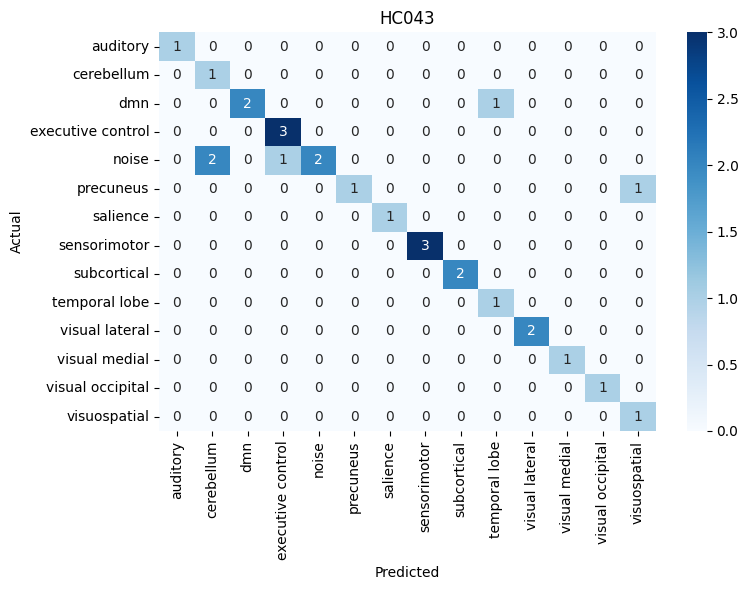

Misclassified Cases:

[5] visuospatial should be precuneus
[7] cerebellum should be noise
[8] executive control should be noise
[11] temporal lobe should be dmn
[24] cerebellum should be noise

Classification Report:
                   precision    recall  f1-score   support

         auditory       1.00      1.00      1.00         1
       cerebellum       1.00      1.00      1.00         2
              dan       0.00      0.00      0.00         1
              dmn       0.50      0.50      0.50         2
executive control       0.67      0.67      0.67         3
            noise       0.67      1.00      0.80         6
        precuneus       1.00      0.50      0.67         4
         salience       1.00      0.50      0.67         2
     sensorimotor       0.75      1.00      0.86         3
      subcortical       1.00      1.00      1.00         1
    temporal lobe       1.00      1.00      1.00         1
   visual lateral       1.00      1.00      1.00         1
    visual medi

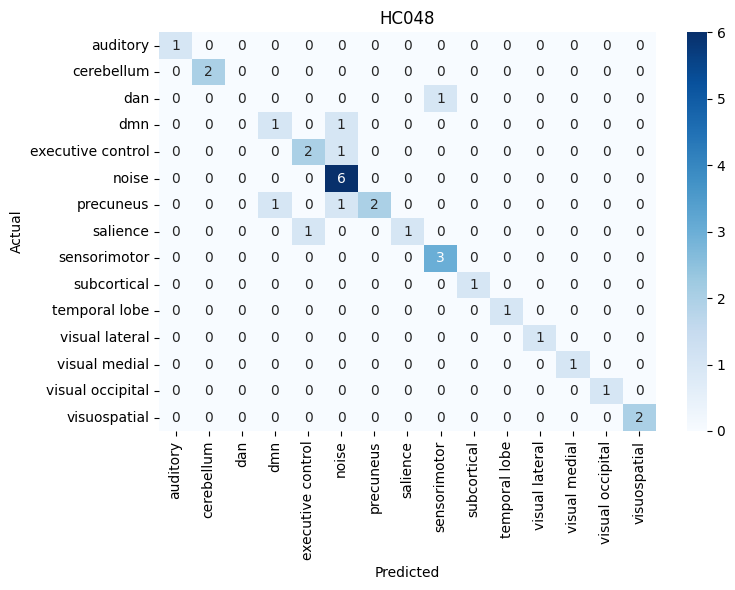

Misclassified Cases:

[1] noise should be executive control
[10] noise should be dmn
[16] executive control should be salience
[20] dmn should be precuneus
[24] sensorimotor should be dan
[30] noise should be precuneus


In [ ]:
# Evaluate HC043 and HC048 performances
misclassified_atoms_HC043, true_atoms_per_atom_HC043, assigned_atoms_per_atom_HC043 = evaluate(
    HC043_atom_dict, actualHC043, outputHC043, "HC043", templates
)
misclassified_atoms_HC048, true_atoms_per_atom_HC048, assigned_atoms_per_atom_HC048 = evaluate(
    HC048_atom_dict, actualHC048, outputHC048, "HC048", templates
)


In [ ]:
misclassified_atoms_HC043

{5: <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a27b0>,
 7: <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a28d0>,
 8: <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a2960>,
 11: <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a3770>,
 24: <nibabel.nifti1.Nifti1Image at 0x7ca1cf678dd0>}

## Visualize misclassified atoms

In [ ]:
# Helper to visualize misclassified cases
import matplotlib.pyplot as plt
from nilearn import plotting, datasets

bg_anatomy = datasets.load_mni152_template(2)


def visualize_misclassification(misclassified_atoms, true_atoms_per_atom, assigned_atoms_per_atom, assigned_name, actual_name):
    """
    Plots each misclassified atom against the wrong assigned template and the true target.
    """

    def _to_3d(img):
        if getattr(img, "ndim", None) == 4:
            return image.mean_img(img)
        return img

    for idx, misclassified_atom in misclassified_atoms.items():
        subj_img = _to_3d(misclassified_atom)

        true_pairs = true_atoms_per_atom.get(idx, [])
        assigned_pairs = assigned_atoms_per_atom.get(idx, [])

        true_imgs = [_to_3d(img) for _, img in true_pairs]
        assigned_imgs = [_to_3d(img) for _, img in assigned_pairs]
        true_names = [name for name, _ in true_pairs]
        assigned_names = [name for name, _ in assigned_pairs]

        assigned_label = assigned_name[idx - 1] if idx - 1 < len(assigned_name) else "unknown"
        actual_label = actual_name[idx - 1] if idx - 1 < len(actual_name) else "unknown"

        print(f"Atom {idx}: actual='{actual_label}', assigned='{assigned_label}', true_templates={len(true_pairs)}, assigned_templates={len(assigned_pairs)}")

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        plotting.plot_stat_map(
            subj_img,
            title=f"ATOM {idx}: Input component",
            display_mode="z",
            cut_coords=4,
            axes=axes[0],
            colorbar=True,
        )

        if assigned_label.lower() == "noise":
            axes[1].axis("off")
            axes[1].set_title("WRONG MATCH: noise")
        elif assigned_pairs:
            for ax, (img, atlas_name) in zip(axes[1:1 + len(assigned_pairs)], zip(assigned_imgs, assigned_names)):
                plotting.plot_stat_map(
                    img,
                    bg_img=bg_anatomy,
                    title=f"WRONG MATCH: '{assigned_label}' with {atlas_name} atlas",
                    display_mode="z",
                    cut_coords=[-10, 0, 10, 20],
                    colorbar=True,
                    cmap="cold_hot",
                    axes=ax,
                )
        else:
            axes[1].axis("off")
            axes[1].set_title("WRONG MATCH: no template available")

        if actual_label.lower() == "noise":
            axes[2].axis("off")
            axes[2].set_title("TRUE TARGET: noise")
        elif true_pairs:
            for ax, (img, atlas_name) in zip(axes[2:2 + len(true_pairs)], zip(true_imgs, true_names)):
                plotting.plot_stat_map(
                    img,
                    bg_img=bg_anatomy,
                    title=f"TRUE TARGET: '{actual_label}' with {atlas_name} atlas",
                    display_mode="z",
                    cut_coords=[-10, 0, 10, 20],
                    colorbar=True,
                    cmap="cold_hot",
                    axes=ax,
                )
        else:
            axes[2].axis("off")
            axes[2].set_title("TRUE TARGET: no template available")

        fig.suptitle(f"Debugging Misclassification for Atom {idx}", fontsize=14, weight="bold")
        fig.tight_layout()
        plt.show()


In [ ]:
# Helper to print top classifications of misclassified
def print_top_misclassified(top_classification_results, output, actual, subject):
    print(f"\n--- Top Results for {subject} ---")
    for net, list_of_atoms in top_classification_results.items():
        if list_of_atoms and output[net-1] != actual[net-1]:
            print(f"[{net}]: Atoms {list_of_atoms}")

In [ ]:
# Helper to print all scores of misclassified
def print_all_scores_misclassified(all_scores, output, actual, subject):
    print(f"\n--- Top Results for {subject} ---")
    for net, list_of_atoms in all_scores.items():
        if list_of_atoms and output[net-1] != actual[net-1]:
            print(f"[{net}]: Atoms {list_of_atoms}")

In [ ]:
true_atoms_per_atom_HC043

{5: [('Smith', <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a1010>),
  ('Schaefer', <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a2210>),
  ('MIST', <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a2e70>)],
 7: [],
 8: [],
 11: [('Smith', <nibabel.nifti1.Nifti1Image at 0x7ca1e0934650>),
  ('Schaefer', <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a1880>),
  ('MIST', <nibabel.nifti1.Nifti1Image at 0x7ca1cf7a2d50>)],
 24: []}

Atom 5: actual='precuneus', assigned='visuospatial', true_templates=3, assigned_templates=2


/tmp/ipykernel_741/3171262905.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


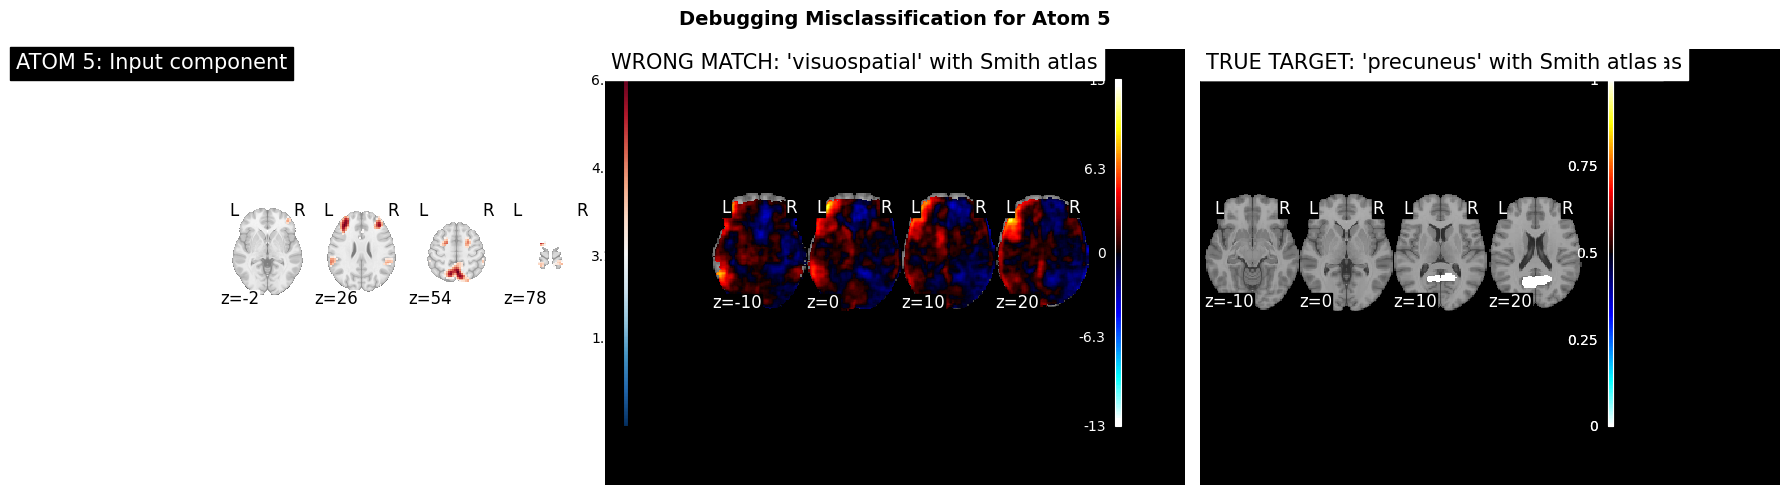

Atom 7: actual='noise', assigned='cerebellum', true_templates=0, assigned_templates=2


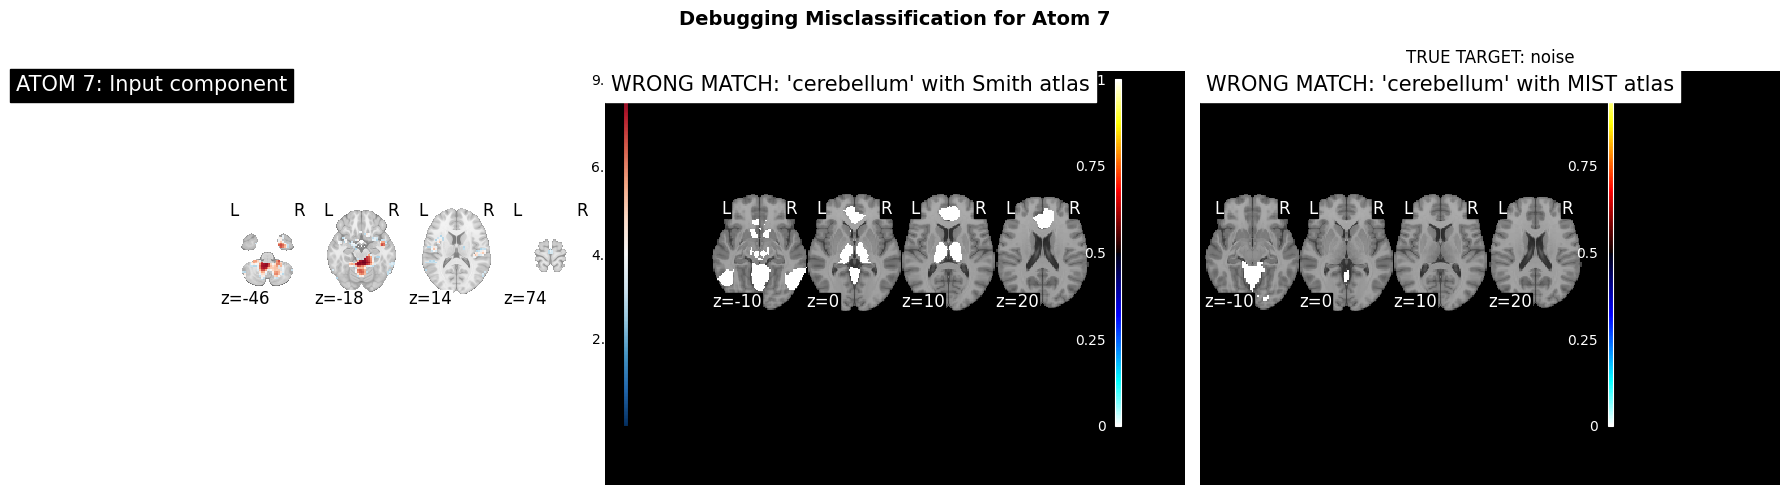

Atom 8: actual='noise', assigned='executive control', true_templates=0, assigned_templates=2


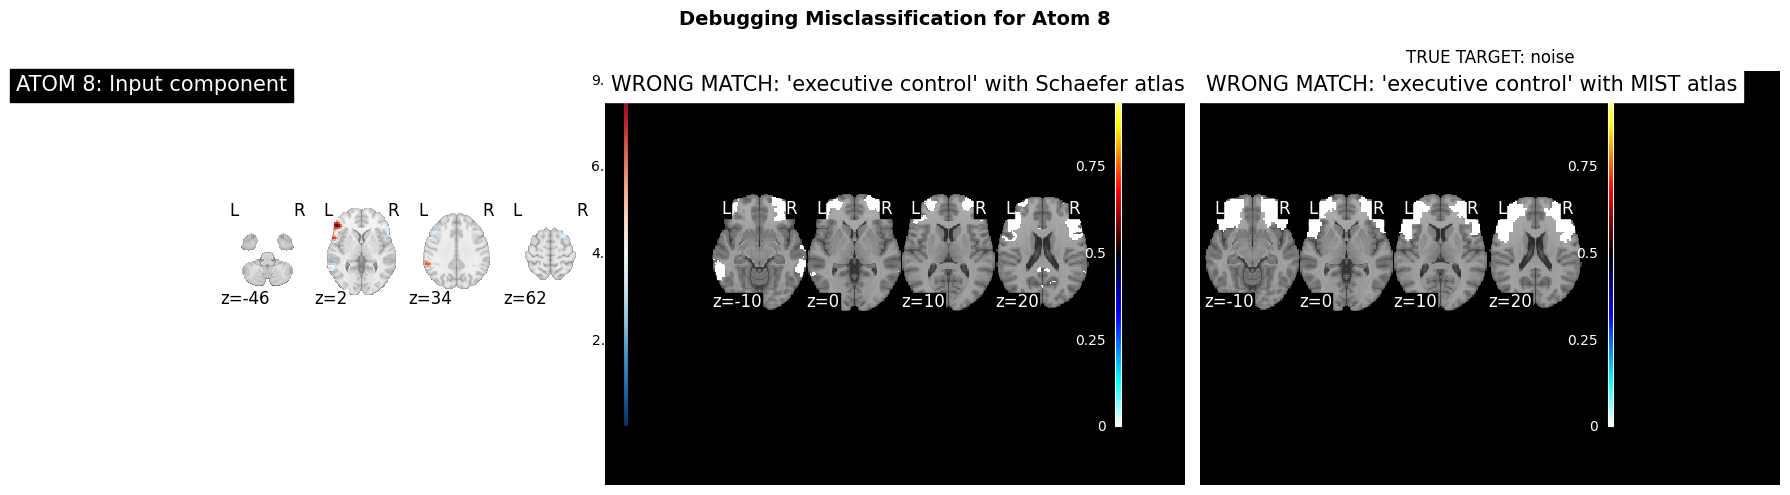

Atom 11: actual='dmn', assigned='temporal lobe', true_templates=3, assigned_templates=2


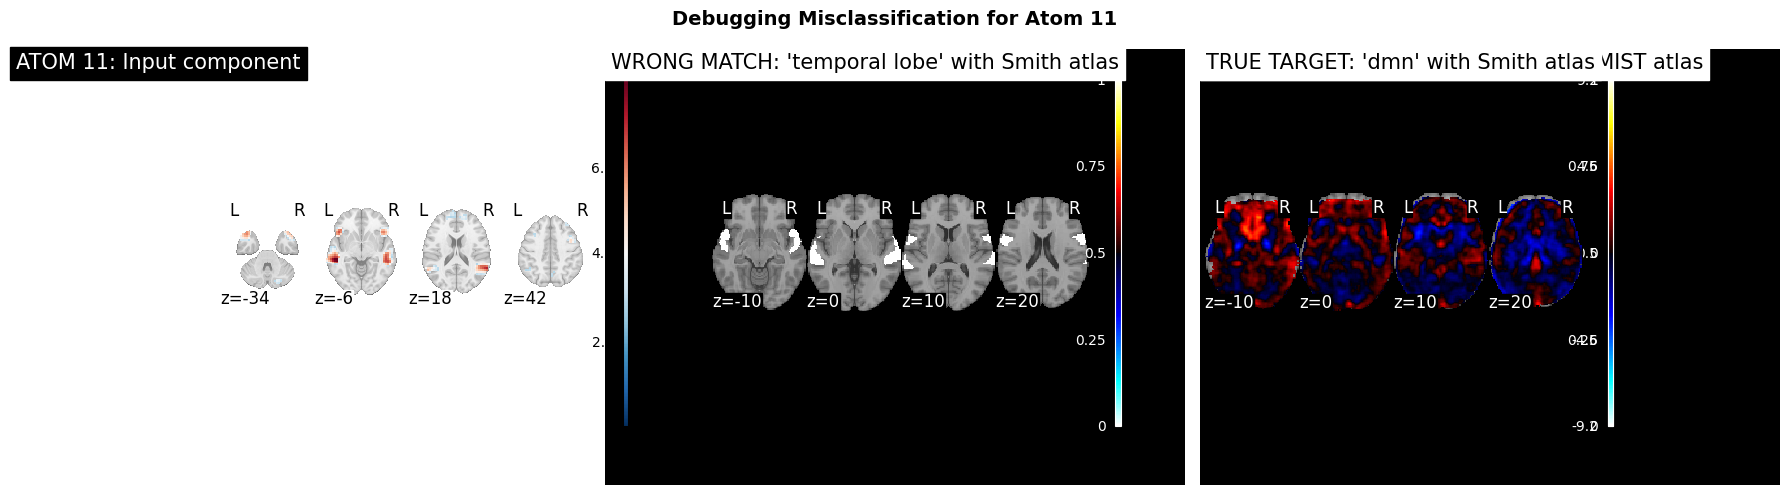

Atom 24: actual='noise', assigned='cerebellum', true_templates=0, assigned_templates=2


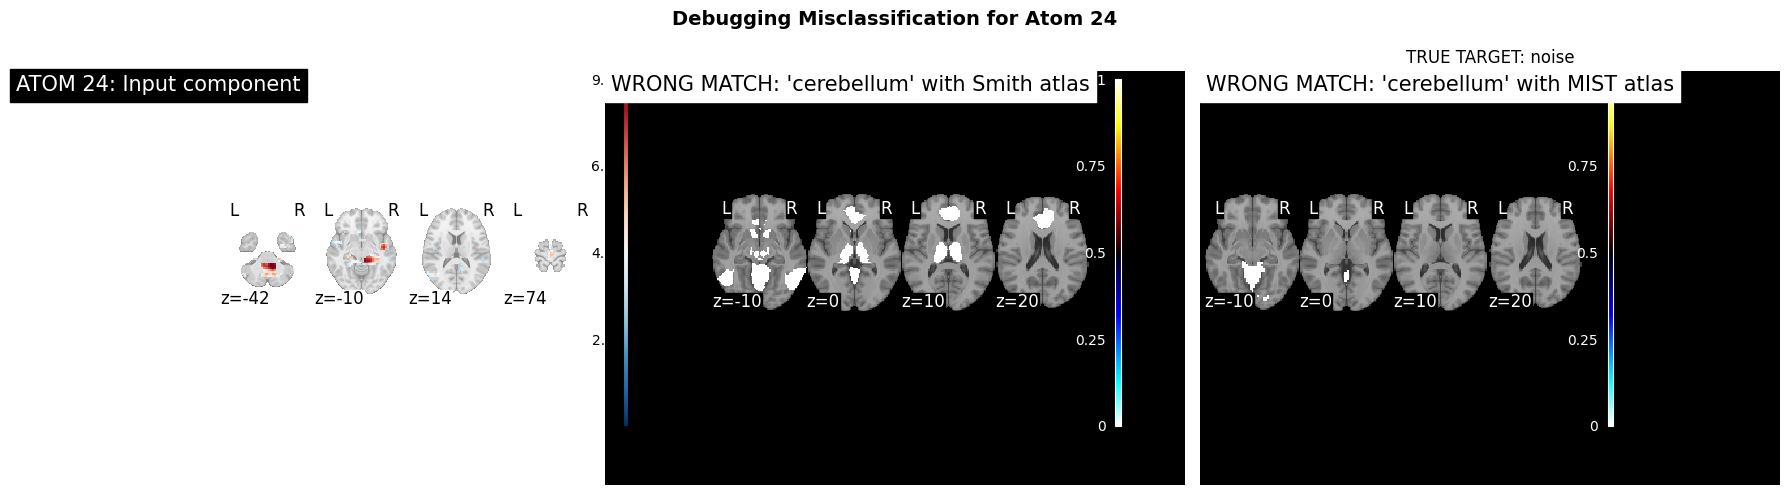

In [ ]:
# Visualize misclassified HC043
visualize_misclassification(misclassified_atoms_HC043, true_atoms_per_atom_HC043, assigned_atoms_per_atom_HC043, outputHC043, actualHC043)

In [ ]:
print_top_misclassified(top_classification_results_HC043, outputHC043, actualHC043, "HC043")


--- Top Results for HC043 ---
[5]: Atoms [{'label': 'visuospatial', 'score': np.float64(0.1824058909931511)}, {'label': 'noise', 'score': np.float64(0.15075790880064233)}, {'label': 'noise', 'score': np.float64(0.14403194316629528)}]
[7]: Atoms [{'label': 'cerebellum', 'score': np.float64(0.2880132524580117)}, {'label': 'noise', 'score': np.float64(0.0868459335703054)}, {'label': 'noise', 'score': np.float64(0.06424181799626058)}]
[8]: Atoms [{'label': 'executive control', 'score': np.float64(0.24503034401250978)}, {'label': 'visuospatial', 'score': np.float64(0.18120194534951414)}, {'label': 'noise', 'score': np.float64(0.06200447417053641)}]
[11]: Atoms [{'label': 'temporal lobe', 'score': np.float64(0.24934132607387868)}, {'label': 'noise', 'score': np.float64(0.17266435646024283)}, {'label': 'noise', 'score': np.float64(0.1359551387579899)}]
[24]: Atoms [{'label': 'cerebellum', 'score': np.float64(0.226985110519977)}, {'label': 'noise', 'score': np.float64(0.11971943940457255)}, {

Atom 1: actual='executive control', assigned='noise', true_templates=2, assigned_templates=0


/tmp/ipykernel_741/3171262905.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


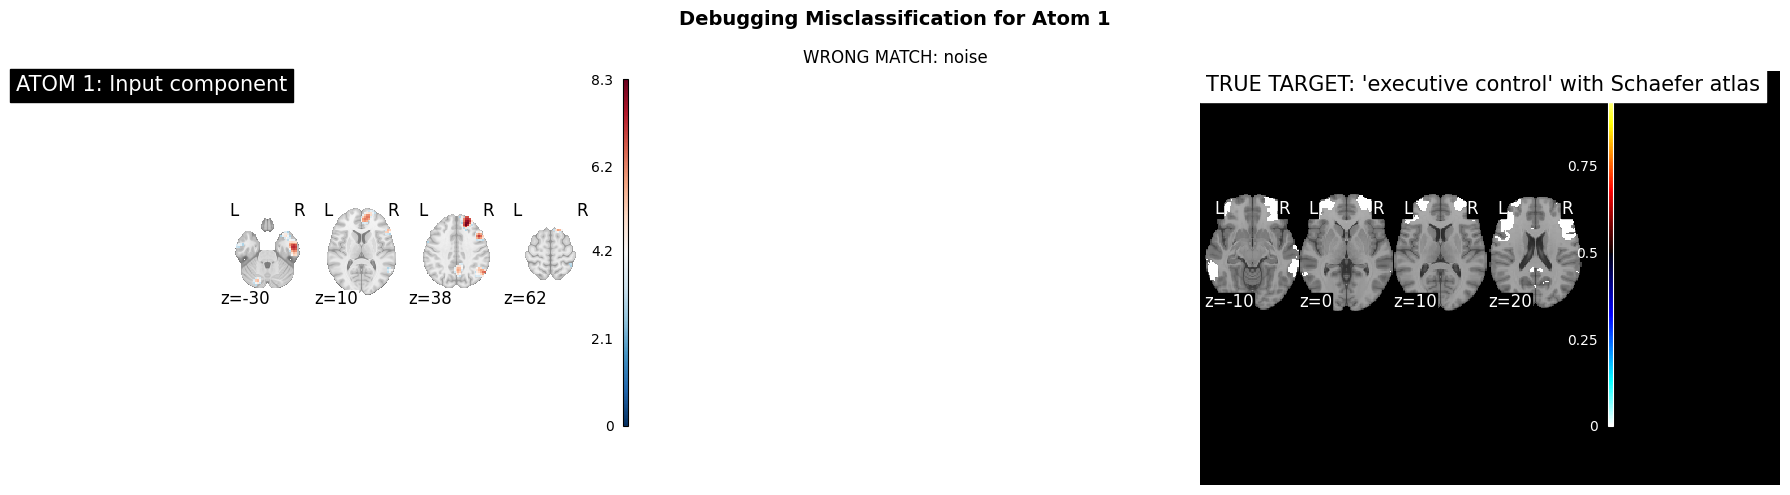

Atom 10: actual='dmn', assigned='noise', true_templates=3, assigned_templates=0


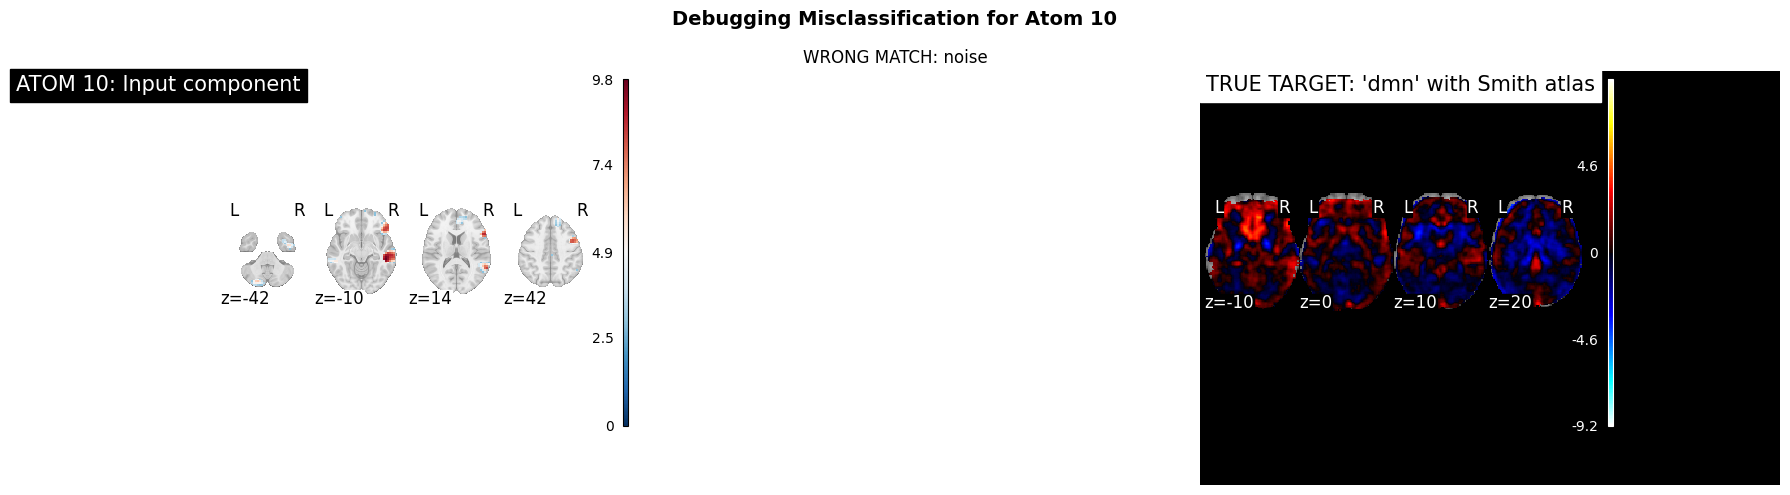

Atom 16: actual='salience', assigned='executive control', true_templates=3, assigned_templates=2


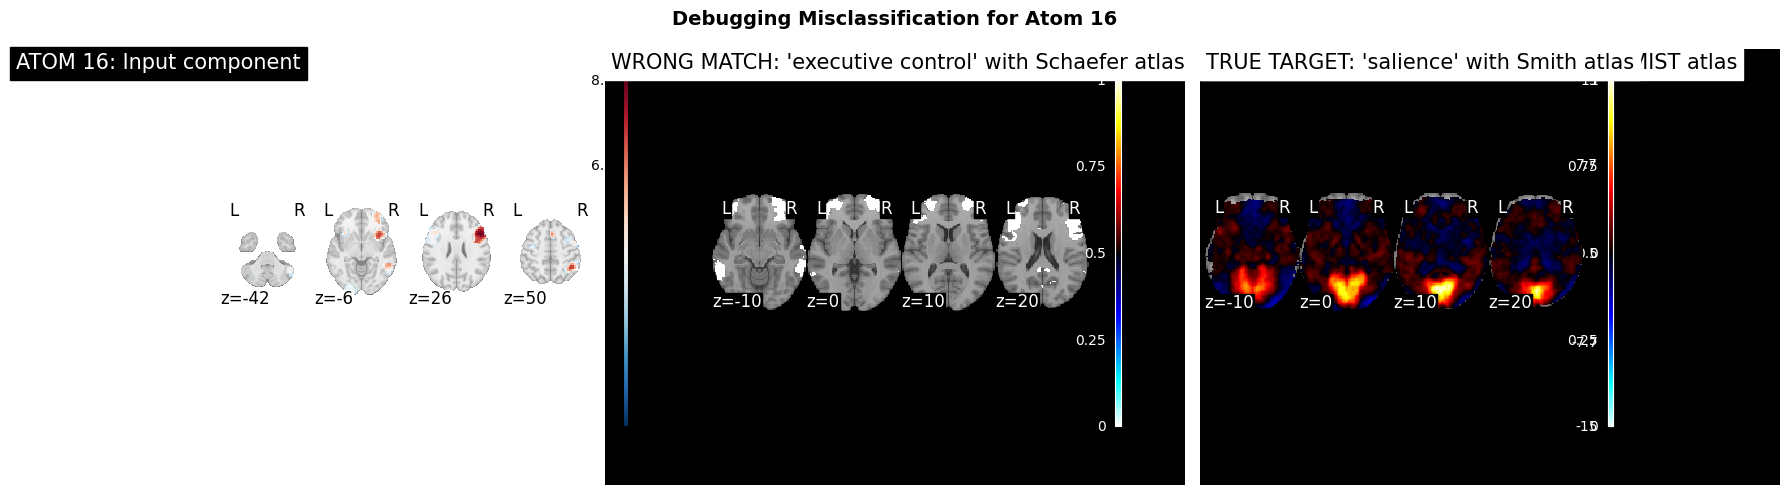

Atom 20: actual='precuneus', assigned='dmn', true_templates=3, assigned_templates=3


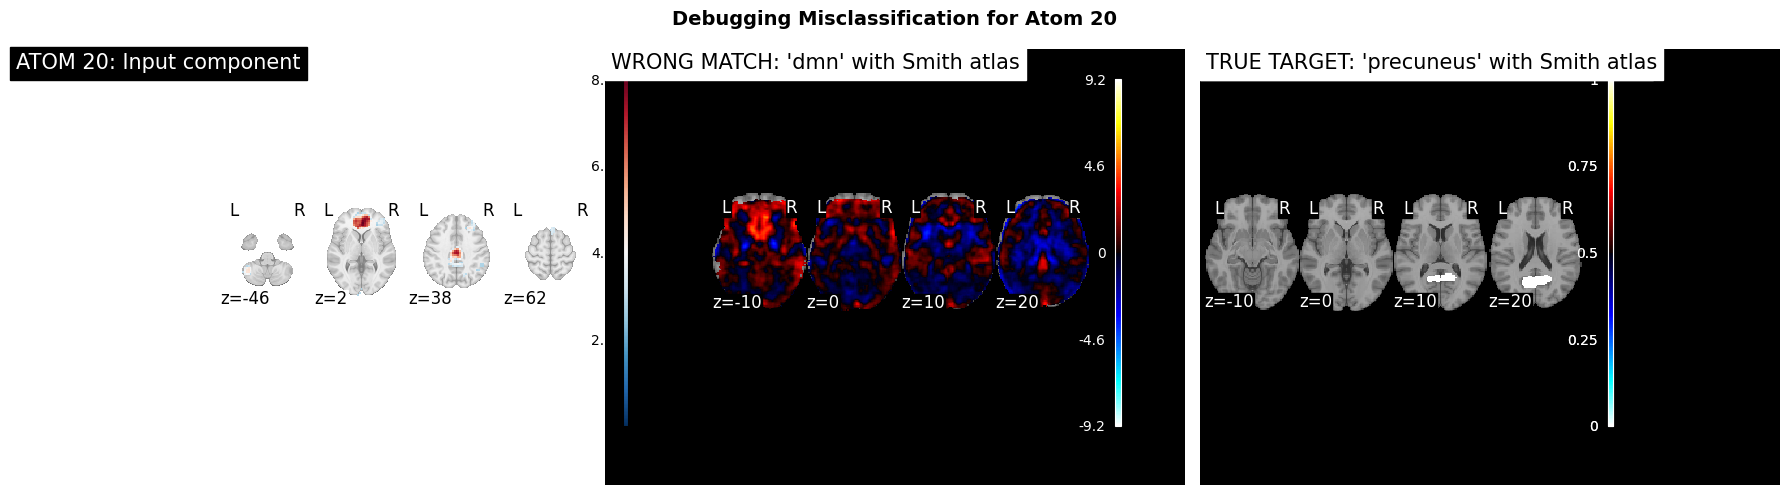

Atom 24: actual='dan', assigned='sensorimotor', true_templates=2, assigned_templates=2


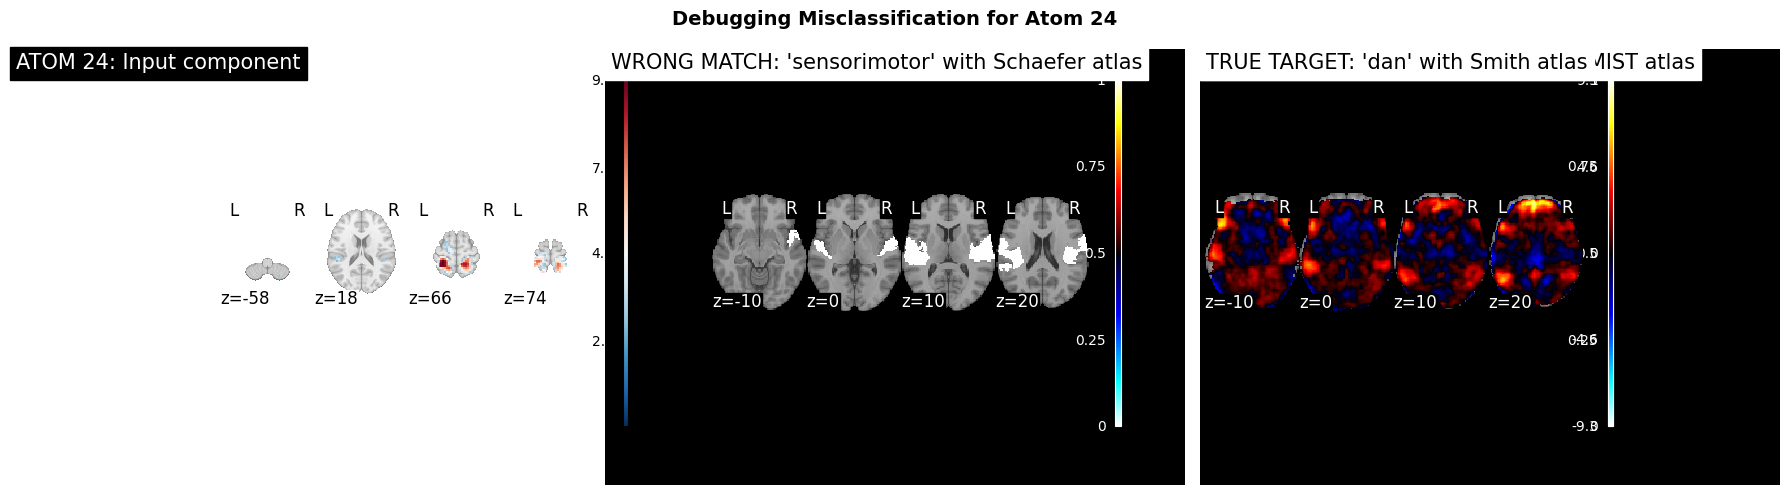

Atom 30: actual='precuneus', assigned='noise', true_templates=3, assigned_templates=0


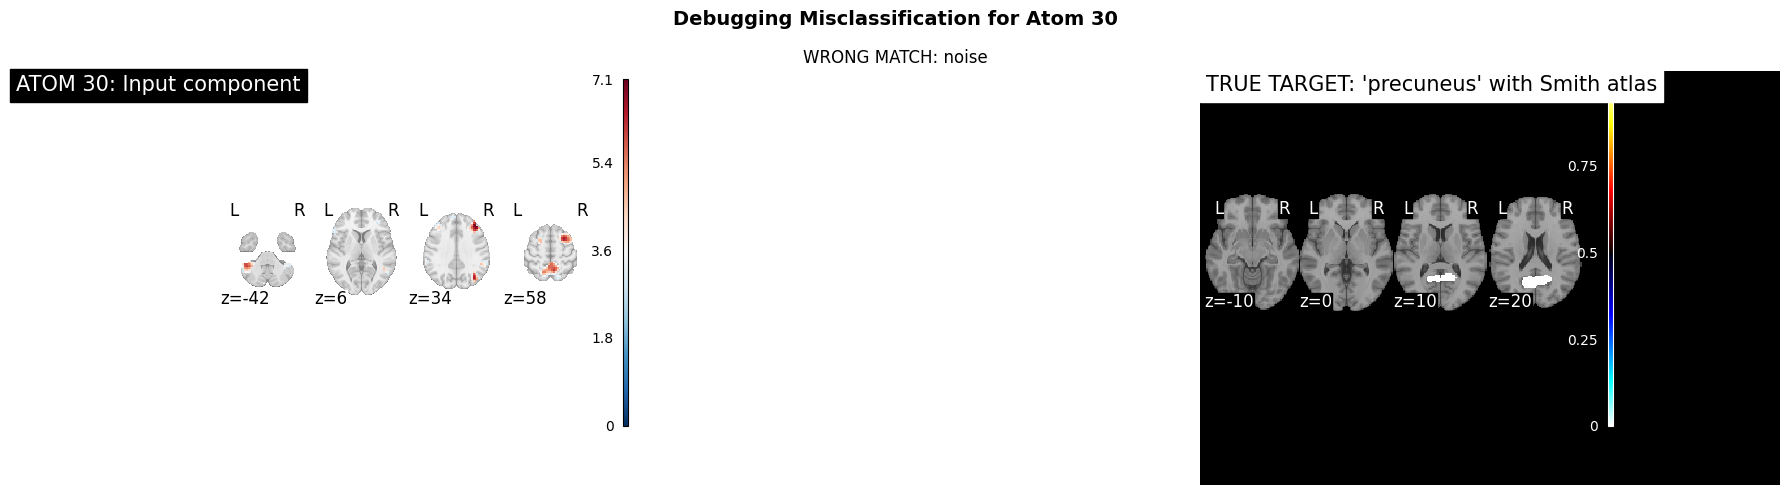

In [ ]:
# Visualize misclassified HC048
visualize_misclassification(misclassified_atoms_HC048, true_atoms_per_atom_HC048, assigned_atoms_per_atom_HC048, outputHC048, actualHC048)

In [ ]:
print_top_misclassified(top_classification_results_HC048, outputHC048, actualHC048, "HC048")


--- Top Results for HC048 ---
[1]: Atoms [{'label': 'noise', 'score': np.float64(0.17448342074682405)}, {'label': 'noise', 'score': np.float64(0.15189347490524802)}, {'label': 'noise', 'score': np.float64(0.1245037335878945)}]
[10]: Atoms [{'label': 'noise', 'score': np.float64(0.17784520302800239)}, {'label': 'noise', 'score': np.float64(0.13111729810077238)}, {'label': 'noise', 'score': np.float64(0.12168892624385064)}]
[16]: Atoms [{'label': 'executive control', 'score': np.float64(0.31586694938016835)}, {'label': 'noise', 'score': np.float64(0.11480352991618102)}, {'label': 'noise', 'score': np.float64(0.09985280623507302)}]
[20]: Atoms [{'label': 'dmn', 'score': np.float64(0.23394266169965705)}, {'label': 'noise', 'score': np.float64(0.09719296043593798)}, {'label': 'noise', 'score': np.float64(0.08526396466207259)}]
[24]: Atoms [{'label': 'sensorimotor', 'score': np.float64(0.21409874981539567)}, {'label': 'noise', 'score': np.float64(0.13463481698140503)}, {'label': 'noise', 's

# Test HC044

In [ ]:
top_classification_results_HC044, all_scores_HC044 = classify_dp(HC044_atom_dict, labels, templates)
classification_results_HC044 = top_result(top_classification_results_HC044)

In [ ]:
actualHC044 = [
    "visuospatial",
    "visual occipital",
    "noise",
    "executive control",
    "noise",
    "sensorimotor",
    "noise",
    "noise",
    "cerebellum",
    "noise",
    "noise",
    "executive control",
    "visual lateral",
    "salience",
    "auditory",
    "executive control",
    "dmn",
    "visual medial",
    "executive control",
    "temporal lobe",
    "precuneus",
    "executive control",
    "noise",
    "salience",
    "dmn",
    "sensorimotor",
    "noise"
]

print(len(actualHC044))

outputHC044 = [classification_results_HC044[i]['label'] for i in range(1, len(classification_results_HC044)+1)]

27



Classification Report:
                   precision    recall  f1-score   support

         auditory       1.00      1.00      1.00         1
       cerebellum       0.50      1.00      0.67         1
              dmn       1.00      0.50      0.67         2
executive control       1.00      0.80      0.89         5
            noise       0.78      0.88      0.82         8
        precuneus       0.50      1.00      0.67         1
         salience       1.00      0.50      0.67         2
     sensorimotor       1.00      1.00      1.00         2
    temporal lobe       1.00      1.00      1.00         1
   visual lateral       1.00      1.00      1.00         1
    visual medial       1.00      1.00      1.00         1
 visual occipital       1.00      1.00      1.00         1
     visuospatial       1.00      1.00      1.00         1

         accuracy                           0.85        27
        macro avg       0.91      0.90      0.88        27
     weighted avg       0.90  

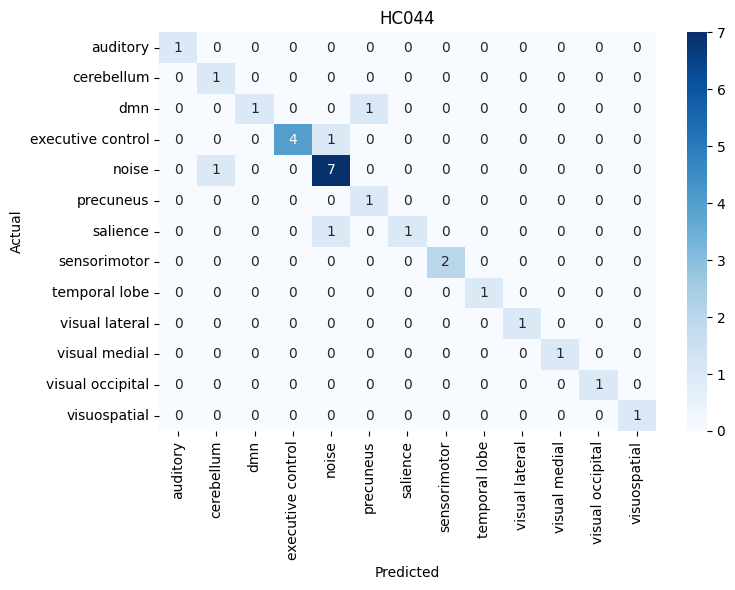

Misclassified Cases:

[16] noise should be executive control
[23] cerebellum should be noise
[24] noise should be salience
[25] precuneus should be dmn


In [ ]:
# Evaluate performance on HC044
misclassified_atoms_HC044, true_atoms_per_atom_HC044, assigned_atoms_per_atom_HC044 = evaluate(
    HC044_atom_dict, actualHC044, outputHC044, "HC044", templates
)

In [ ]:
print_all_scores_misclassified(top_classification_results_HC048,outputHC048,actualHC048,"HC048")


--- Top Results for HC048 ---
[1]: Atoms [{'label': 'noise', 'score': np.float64(0.17448342074682405)}, {'label': 'noise', 'score': np.float64(0.15189347490524802)}, {'label': 'noise', 'score': np.float64(0.1245037335878945)}]
[10]: Atoms [{'label': 'noise', 'score': np.float64(0.17784520302800239)}, {'label': 'noise', 'score': np.float64(0.13111729810077238)}, {'label': 'noise', 'score': np.float64(0.12168892624385064)}]
[16]: Atoms [{'label': 'executive control', 'score': np.float64(0.31586694938016835)}, {'label': 'noise', 'score': np.float64(0.11480352991618102)}, {'label': 'noise', 'score': np.float64(0.09985280623507302)}]
[20]: Atoms [{'label': 'dmn', 'score': np.float64(0.23394266169965705)}, {'label': 'noise', 'score': np.float64(0.09719296043593798)}, {'label': 'noise', 'score': np.float64(0.08526396466207259)}]
[24]: Atoms [{'label': 'sensorimotor', 'score': np.float64(0.21409874981539567)}, {'label': 'noise', 'score': np.float64(0.13463481698140503)}, {'label': 'noise', 's